In [16]:
import pandas as pd
import matplotlib.pyplot as plt

talks_df = pd.read_excel("German_original_TED_talks.xlsx")
# Keep only rows with valid year and domain
timeline_df = (
    talks_df[["Year", "Domain"]]
    .dropna()
    .copy()
)

timeline_df["Year"] = timeline_df["Year"].astype(int)

# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

summary = (
    timeline_df
    .groupby("Domain")
    .agg(
        Earliest_Year=("Year", "min"),
        Latest_Year=("Year", "max"),
        Number_of_Talks=("Year", "count")
    )
    .sort_values("Earliest_Year")
)

print(summary)

# ------------------------------------------------------------
# Timeline (strip plot)
# ------------------------------------------------------------

domains = summary.index.tolist()


                  Earliest_Year  Latest_Year  Number_of_Talks
Domain                                                       
Education                  2010         2025               10
Business                   2011         2025               10
Entertainment              2013         2025               10
Medicine                   2013         2025               10
Art                        2014         2025               10
Science                    2014         2025               10
History                    2016         2025               10
Technology                 2019         2025               10
Philosophy                 2022         2025               10
Politics and Law           2023         2025               10
Psychology                 2023         2025               10


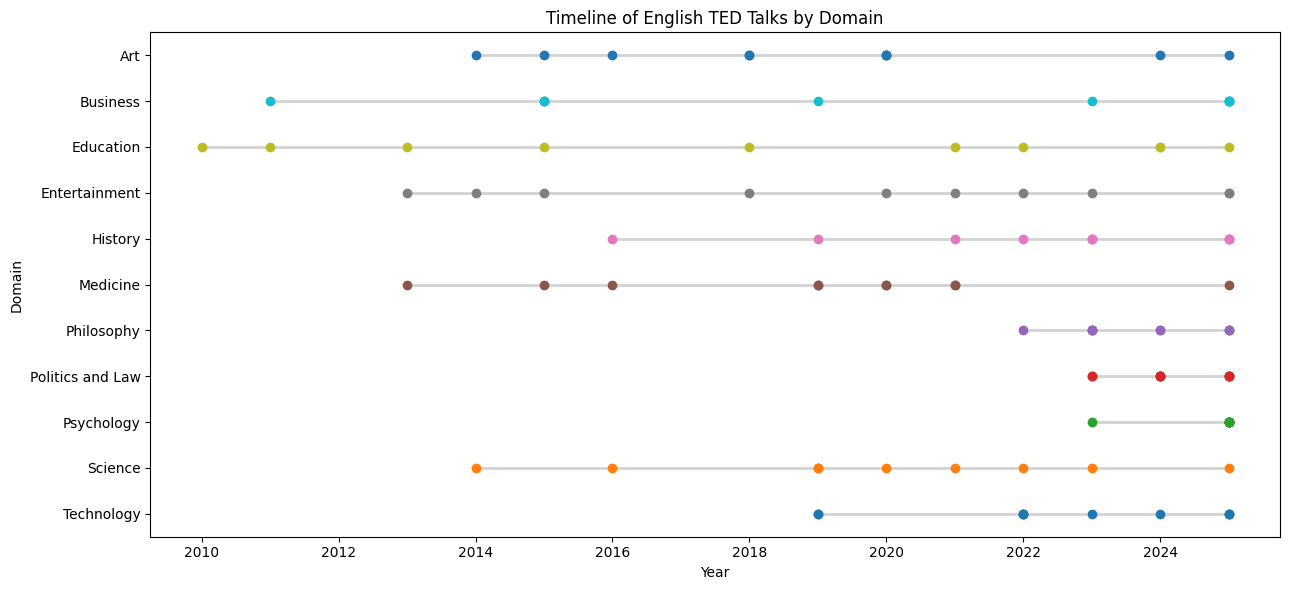

In [ ]:
fig, ax = plt.subplots(figsize=(13,6))

domains = sorted(timeline_df["Domain"].unique(), reverse=True)


for i, domain in enumerate(domains):

    years = timeline_df.loc[
        timeline_df["Domain"] == domain,
        "Year"
    ]

    # horizontal timeline
    ax.hlines(i,
              years.min(),
              years.max(),
              color="lightgray",
              linewidth=2)

    # talks
    ax.plot(
        years,
        [i]*len(years),
        "o",
        markersize=6
    )

ax.set_yticks(range(len(domains)))
ax.set_yticklabels(domains)

ax.set_xlabel("Year")
ax.set_ylabel("Domain")
ax.set_title("Timeline of English TED Talks by Domain")

plt.tight_layout()
plt.show()

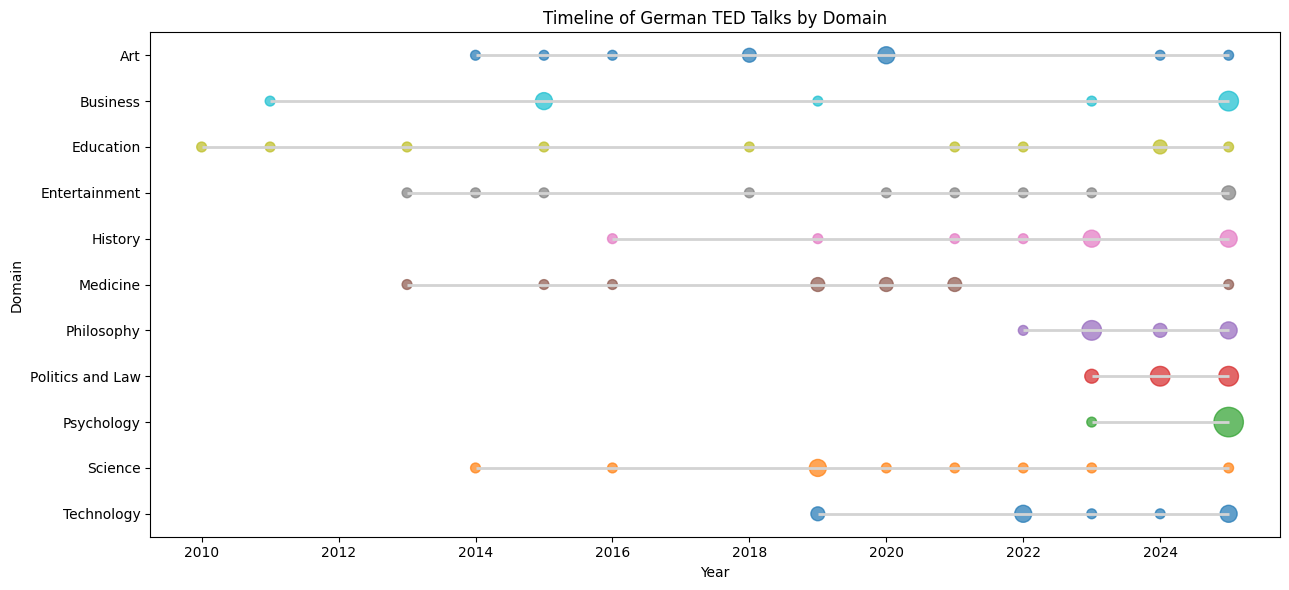

In [24]:
import numpy as np
fig, ax = plt.subplots(figsize=(13,6))

domains = sorted(timeline_df["Domain"].unique(), reverse=True)

for i, domain in enumerate(domains):

    domain_data = timeline_df[timeline_df["Domain"] == domain]

    # Count talks per year
    year_counts = (
        domain_data.groupby("Year")
        .size()
        .reset_index(name="Count")
    )

    # Horizontal timeline
    ax.hlines(
        i,
        year_counts["Year"].min(),
        year_counts["Year"].max(),
        color="lightgray",
        linewidth=2
    )

    # Bubble size proportional to number of talks
    ax.scatter(
        year_counts["Year"],
        [i] * len(year_counts),
        s=year_counts["Count"] * 50,   # Adjust 50 to control bubble size
        alpha=0.7
    )



ax.set_yticks(range(len(domains)))
ax.set_yticklabels(domains)

ax.set_xlabel("Year")
ax.set_ylabel("Domain")
ax.set_title("Timeline of German TED Talks by Domain")

plt.tight_layout()
plt.show()